In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

data = pd.read_csv("data.csv")

# reduce size for speed
data = data.sample(5000, random_state=42)

print(data.head())

            FILENAME                                                URL  \
136221    827598.txt                          https://www.northcm.ac.th   
56609   oph00308.txt  https://unitedmartialartscenters.com/at0/mygov...   
46393    8112660.txt  https://email.mail1.onesignal.os.tc/c/ejwcz02u...   
129746   8135291.txt                                http://uqr.to/1il1z   
131464    586561.txt               https://www.woolworthsrewards.com.au   

        URLLength                        Domain  DomainLength  IsDomainIP  \
136221         24             www.northcm.ac.th            17           0   
56609          59  unitedmartialartscenters.com            28           0   
46393         385   email.mail1.onesignal.os.tc            27           0   
129746         19                        uqr.to             6           0   
131464         35  www.woolworthsrewards.com.au            28           0   

        TLD  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  \
13622

In [2]:
print("Shape:", data.shape)
print("Missing:", data.isnull().sum().sum())

Shape: (5000, 56)
Missing: 0


In [3]:
data.fillna(data.mean(numeric_only=True), inplace=True)

for col in data.select_dtypes('object'):
    data[col] = LabelEncoder().fit_transform(data[col])

# CHANGE 'label' if needed
X = data.drop('label', axis=1)
y = data['label']

print("Preprocessing Done")

Preprocessing Done


In [4]:
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Linear
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Ridge
ridge = Ridge(alpha=1).fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso
lasso = Lasso(alpha=0.1).fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

Linear MSE: 0.01374745274484942
Ridge MSE: 0.01413133125528815
Lasso MSE: 0.036689456006021526


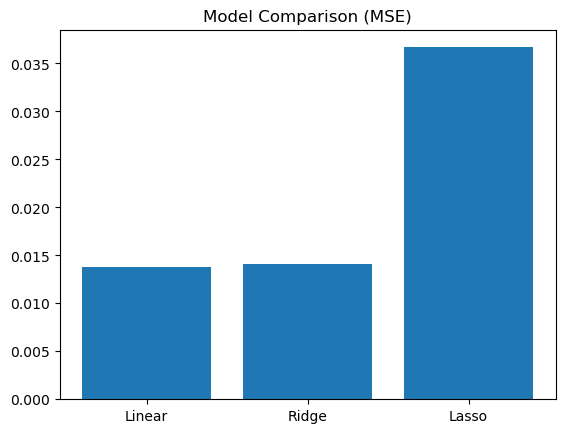

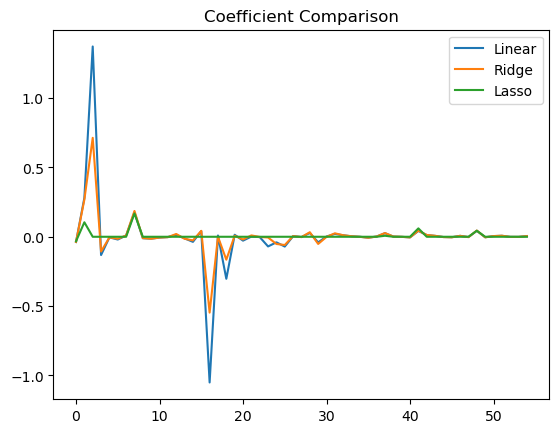

In [6]:
# MSE
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print("Linear MSE:", mse_lr)
print("Ridge MSE:", mse_ridge)
print("Lasso MSE:", mse_lasso)

# Graph: MSE Comparison
plt.bar(["Linear", "Ridge", "Lasso"], [mse_lr, mse_ridge, mse_lasso])
plt.title("Model Comparison (MSE)")
plt.show()

# Coefficient Comparison
plt.plot(lr.coef_, label="Linear")
plt.plot(ridge.coef_, label="Ridge")
plt.plot(lasso.coef_, label="Lasso")
plt.legend()
plt.title("Coefficient Comparison")
plt.show()